In [39]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential

train=pd.read_csv("engtamilTrain.csv", encoding='latin1', engine='python', on_bad_lines='skip')
train=train.drop(["Unnamed: 0"],axis=1)
english_sentences=train["en"]
tamil_sentence=train['ta']
english_sentences=english_sentences.head(1000)
tamil_sentences=tamil_sentence.head(1000)

| **Code**                                                                                            | **Description**                                                                                                                                                                                              |
| --------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `import pandas as pd`                                                                               | Imports the **Pandas** library for reading and manipulating datasets. `pd` is the alias used for Pandas.                                                                                                     |
| `import numpy as np`                                                                                | Imports the **NumPy** library for numerical computations and array operations. `np` is the alias for NumPy.                                                                                                  |
| `import tensorflow as tf`                                                                           | Imports the **TensorFlow** deep learning framework. `tf` is the alias for TensorFlow.                                                                                                                        |
| `from tensorflow import keras`                                                                      | Imports the **Keras API** from TensorFlow to build and train deep learning models.                                                                                                                           |
| `from tensorflow.keras.layers import Embedding, LSTM, Dense`                                        | Imports the required neural network layers: **Embedding** (word vectors), **LSTM** (sequence learning), and **Dense** (output layer).                                                                        |
| `from tensorflow.keras.models import Sequential`                                                    | Imports the **Sequential** model, which allows stacking layers one after another.                                                                                                                            |
| `train = pd.read_csv("engtamilTrain.csv", encoding='latin1', engine='python', on_bad_lines='skip')` | Reads the **English-Tamil translation dataset** from a CSV file. `encoding='latin1'` handles special characters, `engine='python'` improves compatibility, and `on_bad_lines='skip'` ignores corrupted rows. |
| `train = train.drop(["Unnamed: 0"], axis=1)`                                                        | Removes the unnecessary column **Unnamed: 0**, which is usually an automatically generated index column.                                                                                                     |
| `english_sentences = train["en"]`                                                                   | Extracts the **English sentence column** (`en`) from the dataset and stores it in `english_sentences`.                                                                                                       |
| `tamil_sentence = train["ta"]`                                                                      | Extracts the **Tamil sentence column** (`ta`) from the dataset and stores it in `tamil_sentence`.                                                                                                            |
| `english_sentences = english_sentences.head(1000)`                                                  | Selects only the **first 1000 English sentences** from the dataset for training or testing.                                                                                                                  |
| `tamil_sentences = tamil_sentence.head(1000)`                                                       | Selects only the **first 1000 Tamil sentences** corresponding to the English sentences.                                                                                                                      |
============

| **Step**         | **Purpose**                                                             |
| ---------------- | ----------------------------------------------------------------------- |
| Import Libraries | Load Pandas, NumPy, TensorFlow, and Keras modules.                      |
| Read Dataset     | Load the English-Tamil translation dataset from the CSV file.           |
| Clean Dataset    | Remove the unwanted `Unnamed: 0` column.                                |
| Extract Columns  | Separate English (`en`) and Tamil (`ta`) sentence columns.              |
| Select Data      | Keep only the first **1000 sentence pairs** for model training/testing. |

============

This preprocessing prepares the dataset for the next stages:

Tokenization
Padding
Word Embedding
LSTM Model Training
English → Tamil Translation Prediction

In [40]:
!pip install gensim
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from matplotlib import pyplot

| **Code**                                | **Description**                                                                                                                                                                             |
| --------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `!pip install gensim`                   | Installs the **Gensim** library, which is used for Natural Language Processing (NLP) tasks such as **Word2Vec**, **FastText**, and **Doc2Vec**.                                             |
| `from gensim.models import Word2Vec`    | Imports the **Word2Vec** model from Gensim. Word2Vec converts words into dense numerical vectors (word embeddings) that capture semantic relationships between words.                       |
| `from sklearn.decomposition import PCA` | Imports **Principal Component Analysis (PCA)**, a dimensionality reduction technique used to reduce high-dimensional word vectors (e.g., 100 dimensions) to 2 dimensions for visualization. |
| `from matplotlib import pyplot`         | Imports **Matplotlib's pyplot** module to create graphs and visualize the word embeddings after PCA reduction.                                                                              |

=========

| **Step**        | **Purpose**                                                      |
| --------------- | ---------------------------------------------------------------- |
| Install Gensim  | Installs the library required for Word2Vec.                      |
| Import Word2Vec | Loads the Word2Vec model to generate word embeddings.            |
| Import PCA      | Reduces high-dimensional word vectors into 2D for visualization. |
| Import Pyplot   | Displays the reduced word vectors as a scatter plot.             |

=======

Role in Word Embedding
----------------------

Text Data
     │
     ▼
Tokenization
     │
     ▼
Word2Vec Model
     │
     ▼
Word Embeddings
(e.g., 100-dimensional vectors)
     │
     ▼
PCA
(Reduces 100D → 2D)
     │
     ▼
Matplotlib
(Visualizes similar words on a graph)

=========

Example

Suppose Word2Vec generates these vectors:

| Word  | 3-D Word Vector    |
| ----- | ------------------ |
| king  | [0.82, 0.65, 0.91] |
| queen | [0.80, 0.68, 0.89] |
| man   | [0.73, 0.40, 0.52] |
| woman | [0.71, 0.43, 0.54] |

========

Since these vectors have multiple dimensions, PCA converts them into 2D coordinates such as:

| Word  | X   | Y   |
| ----- | --- | --- |
| king  | 2.1 | 1.5 |
| queen | 2.0 | 1.6 |
| man   | 0.8 | 0.4 |
| woman | 0.9 | 0.5 |

Finally, Matplotlib plots these points so that semantically similar words (such as king and queen) appear close together.

In [41]:
def sentToken(sentence):
        # define your dataset
    dataset = sentence

    # convert each sentence to a list of words
    sentences = [sentence.split() for sentence in dataset]

    # print the result
    print(sentences)

    return sentences


| **Code**                                                 | **Description**                                                                                                                                                    |
| -------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `def sentToken(sentence):`                               | Defines a function named **`sentToken()`** that accepts a parameter called `sentence`. This function converts each sentence into a list of words (tokenization).   |
| `dataset = sentence`                                     | Stores the input sentences in the variable `dataset`.                                                                                                              |
| `sentences = [sentence.split() for sentence in dataset]` | Uses **List Comprehension** to iterate through each sentence in the dataset. The `split()` function separates each sentence into individual words based on spaces. |
| `print(sentences)`                                       | Prints the tokenized sentences to verify the output.                                                                                                               |
| `return sentences`                                       | Returns the list of tokenized sentences for further processing (e.g., Word2Vec training).                                                                          |

==========

Work flow

| **Step**           | **Purpose**                                                         |
| ------------------ | ------------------------------------------------------------------- |
| Define Function    | Creates the `sentToken()` function.                                 |
| Store Dataset      | Saves the input sentences into the `dataset` variable.              |
| Tokenize Sentences | Splits every sentence into individual words using `split()`.        |
| Display Output     | Prints the tokenized sentences.                                     |
| Return Tokens      | Returns the tokenized sentences for the next step (Word Embedding). |

======

Data flow

Raw Sentences
      │
      ▼
sentToken()
      │
      ▼
Tokenized Sentences
(List of Word Lists)
      │
      ▼
Word2Vec Model
      │
      ▼
Word Embeddings (Word Vectors)

In [42]:
engSentence=sentToken(english_sentences)

[['MMA', 'vice', 'president', 'Qazi', 'Hussain', 'Ahmad', 'declared', 'last', 'month:', "'We", 'are', 'not', 'extremists.'], ['Information', 'has', 'surfaced', 'in', 'recent', 'years', 'suggesting', 'that', 'Julius', 'Rosenberg', 'was', 'involved', 'in', 'passing', 'some', 'form', 'of', 'intelligence', 'to', 'Soviet', 'officials', 'during', 'the', 'Second', 'World', 'War.'], ['And', 'Azor', 'begat', 'Sadoc;', 'and', 'Sadoc', 'begat', 'Achim;', 'and', 'Achim', 'begat', 'Eliud;'], ['She', 'says', 'she', 'knows', 'what', 'is', 'going', 'on,', 'but', 'can', 'do', 'nothing', 'about', 'it.'], ['And', 'be', 'it', 'indeed', 'that', 'I', 'have', 'erred,', 'my', 'error', 'remains', 'with', 'myself.'], ['Finally,', 'the', 'columnist', 'fails', 'to', 'tell', 'us', 'who', 'among', 'the', 'political', 'leaders', 'of', 'the', 'bourgeoisie,', 'past', 'and', 'present,', 'he', 'counts', 'among', 'the', 'paragons', 'of', 'morality.'], ['These', 'include', 'the', 'British', 'Tamil', 'Forum,', 'La', 'Maiso

| **Code**                                     | **Description**                                                                                                                                                                                              |
| -------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `engSentence = sentToken(english_sentences)` | Calls the `sentToken()` function and passes the `english_sentences` dataset as input. The function tokenizes each English sentence into a list of words and stores the result in the variable `engSentence`. |


=======

| **Step**                       | **Purpose**                                                 |
| ------------------------------ | ----------------------------------------------------------- |
| `english_sentences`            | Contains the original English sentences.                    |
| `sentToken(english_sentences)` | Splits every sentence into individual words (tokenization). |
| `engSentence`                  | Stores the tokenized sentences (list of word lists).        |


=========

english_sentences
        │
        ▼
sentToken(english_sentences)
        │
        ▼
Sentence 1 → split() → ['I', 'love', 'machine', 'learning']
Sentence 2 → split() → ['Word', 'embedding', 'is', 'useful']
Sentence 3 → split() → ['Deep', 'learning', 'is', 'powerful']
        │
        ▼
engSentence

In [43]:
train = pd.read_csv(
    "engtamilTrain.csv",
    encoding="utf-8"
)

In [44]:
train = pd.read_csv("engtamilTrain.csv", encoding="utf-8")

train = train.drop(["Unnamed: 0"], axis=1)

english_sentences = train["en"]
tamil_sentences = train["ta"]

english_sentences = english_sentences.head(1000)
tamil_sentences = tamil_sentences.head(1000)

| **Code**                                                     | **Description**                                                                                                            |
| ------------------------------------------------------------ | -------------------------------------------------------------------------------------------------------------------------- |
| `train = pd.read_csv("engtamilTrain.csv", encoding="utf-8")` | Reads the **English-Tamil CSV dataset** using **UTF-8 encoding**, which correctly loads Tamil Unicode characters.          |
| `train = train.drop(["Unnamed: 0"], axis=1)`                 | Removes the unnecessary **`Unnamed: 0`** column from the dataset. This column is usually an automatically generated index. |
| `english_sentences = train["en"]`                            | Extracts the **English sentence** column (`en`) from the dataset.                                                          |
| `tamil_sentences = train["ta"]`                              | Extracts the **Tamil sentence** column (`ta`) from the dataset.                                                            |
| `english_sentences = english_sentences.head(1000)`           | Selects the **first 1000 English sentences** for training or testing.                                                      |
| `tamil_sentences = tamil_sentences.head(1000)`               | Selects the **first 1000 Tamil sentences** corresponding to the English sentences.                                         |


In [45]:
tamSentence = sentToken(tamil_sentences)

[['MMA', 'கட்சியின்', 'துணைத்தலைவர்', 'க்வாஸி', 'ஹுசேன்', 'அகமத்', 'சென்ற', 'மாதம்', 'பின்வருமாறு', 'அறிவித்தார்:', '``நாங்கள்', 'தீவிரவாதிகள்', 'அல்ல.'], ['சமீபகாலத்தில்', 'சில', 'தகவல்கள்', 'யூலியஸ்', 'ரோசன்பேர்க்', 'ஒரு', 'வித', 'உளவுச்செய்தியை', 'சோவியத்', 'அதிகாரிகளுக்கு', 'இரண்டாம்', 'உலகப்போரின்போது', 'அனுப்பியதில்', 'சம்பந்தப்பட்டு', 'இருந்ததாக', 'வெளிவந்துள்ளன.'], ['ஆசோர்', 'சாதோக்கைப்', 'பெற்றான்;', 'சாதோக்கு', 'ஆகீமைப்', 'பெற்றான்;', 'ஆகீம்', 'எலியூதைப்', 'பெற்றான்;'], ['என்ன', 'நடக்கிறது', 'என்பது', 'தமக்கு', 'தெரியும்', 'என்றும்', 'ஆனால்,', 'தம்மால்', 'எதுவும்', 'செய்யமுடியாது', 'என்றும்', 'கடிதம்', 'எழுதியிருந்தார்.'], ['நான்', 'தப்பிநடந்தது', 'மெய்யானாலும்,', 'என்', 'தப்பிதம்', 'என்னோடேதான்', 'இருக்கிறது'], ['டால்ரிம்பிளினுடைய', 'அறிவுஜீவித்', 'தொடுவானத்திற்கு', 'அப்பால்', 'எவ்வளவோ', 'தொலைவில்', 'இருந்தன'], ['இந்த', 'அமைப்புக்களில்', 'British', 'Tamil', 'Forum,', 'La', 'Maison', 'du', 'Tamil', 'Eelam', '(France),', 'the', 'Canadian', 'Tamil', 'Congress,', 'Swiss',

| **Code**                                   | **Description**                                                                                                                                                                                                                         |
| ------------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `tamSentence = sentToken(tamil_sentences)` | Calls the **`sentToken()`** function and passes the `tamil_sentences` dataset as input. The function tokenizes each Tamil sentence by splitting it into individual words and stores the tokenized output in the variable `tamSentence`. |


==========

Work flow

| **Step**                     | **Purpose**                                                                                 |
| ---------------------------- | ------------------------------------------------------------------------------------------- |
| `tamil_sentences`            | Contains the original Tamil sentences from the dataset.                                     |
| `sentToken(tamil_sentences)` | Splits each Tamil sentence into individual words using the `split()` method (tokenization). |
| `tamSentence`                | Stores the tokenized Tamil sentences as a list of word lists.                               |


=========

| **Step**                     | **Purpose**                                                                                 |
| ---------------------------- | ------------------------------------------------------------------------------------------- |
| `tamil_sentences`            | Contains the original Tamil sentences from the dataset.                                     |
| `sentToken(tamil_sentences)` | Splits each Tamil sentence into individual words using the `split()` method (tokenization). |
| `tamSentence`                | Stores the tokenized Tamil sentences as a list of word lists.                               |


====

Input (tamil_sentences)
[
    "நான் தமிழ் கற்கிறேன்",
    "எனக்கு இயந்திர கற்றல் பிடிக்கும்",
    "வேர்ட் எம்பெட்டிங் மிகவும் பயனுள்ளது"
]


Function Call

tamSentence = sentToken(tamil_sentences)

Output (tamSentence)
[
    ['நான்', 'தமிழ்', 'கற்கிறேன்'],
    ['எனக்கு', 'இயந்திர', 'கற்றல்', 'பிடிக்கும்'],
    ['வேர்ட்', 'எம்பெட்டிங்', 'மிகவும்', 'பயனுள்ளது']
]

================


Data Flow
Tamil Sentences
       │
       ▼
sentToken(tamil_sentences)
       │
       ▼
Split Each Sentence into Words
       │
       ▼
Tokenized Tamil Sentences
(List of Word Lists)
       │
       ▼
tamSentence

In [46]:
#https://radimrehurek.com/gensim_3.8.3/models/word2vec.html
#https://radimrehurek.com/gensim/models/word2vec.html

These links are kept as reference documentation so that quickly access:

Word2Vec syntax
Model parameters
Training examples
Saving and loading models
Similarity between words
Word vector extraction
Updated features in newer Gensim versions

In [50]:
def ownWordModel(langsentence,modelname):
    from gensim.models import Word2Vec
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt
    model = Word2Vec(langsentence, min_count=1)
    print(model)
    # save model
    model.save(modelname)
    # fit a 2d PCA model to the vectors
    X = model.wv.vectors  # corrected line
    pca = PCA(n_components=2)
    result = pca.fit_transform(X)

    # create a scatter plot of the projection
    plt.scatter(result[:, 0], result[:, 1])
    words = list(model.wv.index_to_key)
    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]))
    plt.show()


| **Code**                                              | **Description**                                                                                                                                                 |
| ----------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `def ownWordModel(langsentence, modelname):`          | Defines a function named **`ownWordModel()`** that trains a Word2Vec model using the given tokenized sentences and saves it with the specified model name.      |
| `from gensim.models import Word2Vec`                  | Imports the **Word2Vec** model from the Gensim library.                                                                                                         |
| `from sklearn.decomposition import PCA`               | Imports **Principal Component Analysis (PCA)** to reduce high-dimensional word vectors into two dimensions for visualization.                                   |
| `import matplotlib.pyplot as plt`                     | Imports the **Matplotlib** library to plot the word embeddings.                                                                                                 |
| `model = Word2Vec(langsentence, min_count=1)`         | Creates and trains a **Word2Vec** model using the tokenized sentences. `min_count=1` means every word that appears at least once is included in the vocabulary. |
| `print(model)`                                        | Displays the summary of the trained Word2Vec model.                                                                                                             |
| `model.save(modelname)`                               | Saves the trained Word2Vec model to a file with the specified name.                                                                                             |
| `X = model.wv.vectors`                                | Retrieves the learned **word vectors (embeddings)** from the trained model. Each word is represented as a numerical vector.                                     |
| `pca = PCA(n_components=2)`                           | Creates a PCA object that reduces the word vectors to **2 dimensions**.                                                                                         |
| `result = pca.fit_transform(X)`                       | Applies PCA to transform the high-dimensional word vectors into two-dimensional coordinates.                                                                    |
| `plt.scatter(result[:, 0], result[:, 1])`             | Creates a **scatter plot** of the reduced 2D word vectors.                                                                                                      |
| `words = list(model.wv.index_to_key)`                 | Retrieves the list of words in the model's vocabulary.                                                                                                          |
| `for i, word in enumerate(words):`                    | Iterates through every word in the vocabulary along with its index.                                                                                             |
| `plt.annotate(word, xy=(result[i, 0], result[i, 1]))` | Places each word as a label at its corresponding position on the scatter plot.                                                                                  |
| `plt.show()`                                          | Displays the final Word2Vec visualization.                                                                                                                      |

======

| **Step**             | **Purpose**                                                          |
| -------------------- | -------------------------------------------------------------------- |
| Define Function      | Creates a reusable function to train and visualize a Word2Vec model. |
| Import Libraries     | Loads Word2Vec, PCA, and Matplotlib.                                 |
| Train Word2Vec Model | Learns word embeddings from the tokenized sentences.                 |
| Print Model          | Displays information about the trained model.                        |
| Save Model           | Saves the trained Word2Vec model for future use.                     |
| Extract Word Vectors | Retrieves the numerical embeddings for each word.                    |
| Apply PCA            | Reduces the embedding dimensions for visualization.                  |
| Create Scatter Plot  | Plots the 2D word vectors.                                           |
| Add Word Labels      | Displays each word at its corresponding point.                       |
| Display Plot         | Shows the Word2Vec embedding visualization.                          |


Word2Vec<vocab=7300, vector_size=100, alpha=0.025>


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 152 (\x98) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 159 (\x9f) missing 

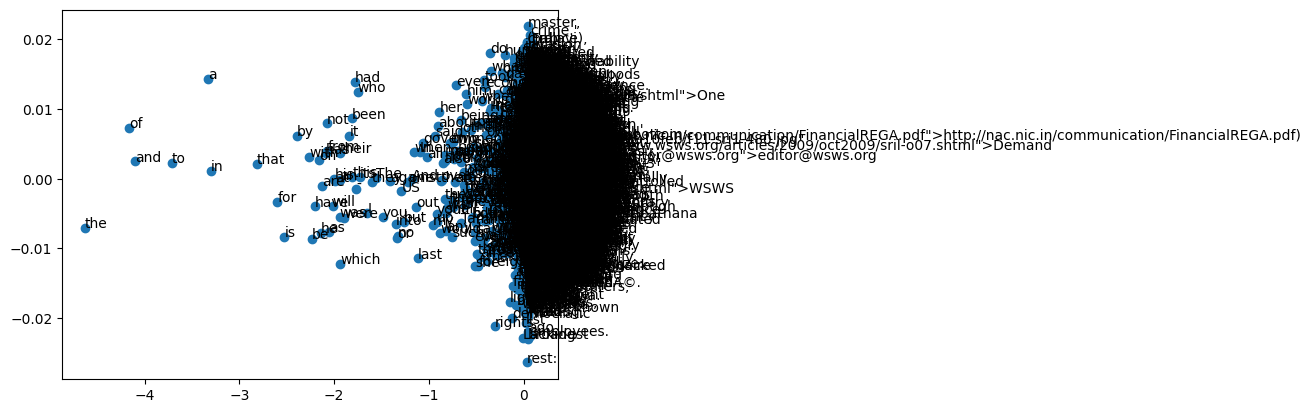

In [48]:
ownWordModel(engSentence,"engmodel.bin")

Word2Vec PCA graph

| **Observation in the Graph**                    | **What You Understood**                                                                                                          |
| ----------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| Each blue dot represents a word.                | Every point on the graph corresponds to one unique word from the English dataset.                                                |
| Words close to each other are grouped together. | These words have **similar meanings** or **appear in similar contexts** in the training sentences.                               |
| Words far apart have different meanings.        | They are used in different contexts and have less semantic similarity.                                                           |
| The graph contains thousands of words.          | Your dataset has a large vocabulary (about **7300 unique words**), making the graph crowded.                                     |
| Many labels overlap.                            | There are too many words to display clearly, so their names overlap and become difficult to read.                                |
| PCA reduced the dimensions.                     | Word2Vec originally learned **100-dimensional vectors**, and **PCA** reduced them to **2 dimensions** so they can be visualized. |
| The X-axis and Y-axis have no direct meaning.   | These axes are the principal components created by PCA. They are used only to visualize relationships between words.             |
| Dense clusters appear in the center.            | Many frequently occurring words have similar vector representations and are grouped together.                                    |
| Some words appear isolated.                     | These words have unique contexts and therefore different embeddings from the majority of the vocabulary.                         |


| **Code**                                    | **Description**                                                                                                                                                                    |
| ------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `ownWordModel(engSentence, "engmodel.bin")` | Calls the `ownWordModel()` function to train a **Word2Vec** model using the tokenized English sentences stored in `engSentence`. The trained model is saved as **`engmodel.bin`**. |


===

| **Step**         | **Purpose**                                                    |
| ---------------- | -------------------------------------------------------------- |
| `engSentence`    | Contains the tokenized English sentences (list of word lists). |
| `ownWordModel()` | Trains the Word2Vec model using the tokenized sentences.       |
| `Word2Vec`       | Learns vector representations (embeddings) for each word.      |
| `engmodel.bin`   | Saves the trained Word2Vec model to a binary file.             |
| `PCA`            | Reduces high-dimensional word vectors to 2 dimensions.         |
| `Scatter Plot`   | Displays the learned word embeddings visually.                 |


====

English Sentences
        │
        ▼
Tokenization (sentToken)
        │
        ▼
engSentence
(List of Word Lists)
        │
        ▼
ownWordModel(engSentence, "engmodel.bin")
        │
        ▼
Train Word2Vec Model
        │
        ▼
Generate Word Embeddings
        │
        ▼
Save Model (engmodel.bin)
        │
        ▼
Apply PCA (2D)
        │
        ▼
Display Word Embedding Graph

====

| **Parameter**     | **Meaning**                                                         |
| ----------------- | ------------------------------------------------------------------- |
| `vocab=7300`      | The model learned **7300 unique words** from the English dataset.   |
| `vector_size=100` | Each word is represented as a **100-dimensional embedding vector**. |
| `alpha=0.025`     | The initial learning rate used by the Word2Vec training algorithm.  |


Word2Vec<vocab=9882, vector_size=100, alpha=0.025>


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2962 (\N{TAMIL LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Tamil natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2992 (\N{TAMIL LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3009 (\N{TAMIL VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2990 (\N{TAMIL LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/I

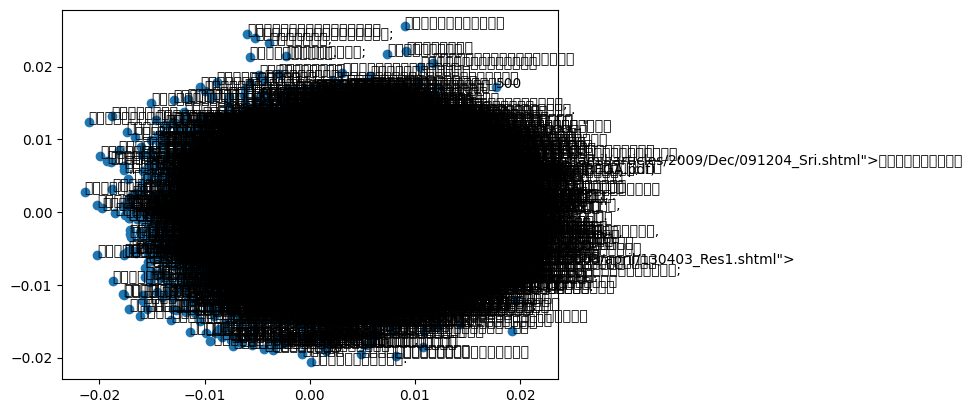

In [49]:
ownWordModel(tamSentence,"tammodel.bin")

In [51]:
from gensim.models import Word2Vec

model = Word2Vec.load("engmodel.bin")

print(model.wv.most_similar("good"))

[('through', 0.9519348740577698), ('could', 0.9514724612236023), ('social', 0.9513323307037354), ('you', 0.9507865309715271), ('opposition', 0.9504889249801636), ('their', 0.9503536224365234), ('when', 0.9502838253974915), ('that', 0.950096070766449), ('new', 0.9499384164810181), ('he', 0.9498174786567688)]
